# 05: Beyond equilibrium: exploiting a suboptimal opponent

A Nash strategy is *provably* over-conservative against a suboptimal opponent: it guarantees you do not lose, but it does not actively punish mistakes (SES, NeurIPS 2022; `docs/V2_RESEARCH_ROADMAP.md`). The one direction with a realistic *positive* result is therefore **exploitation**: detect an opponent's leak and deviate to attack it.

This notebook is the full exploitation arc, and it is the project's strongest story. It runs in three steps:

1. **§13, a pre-registered negative.** A tilt-conditioned policy knob, motivated by the textbook counter to tilt, backfired in a powered test. The story of how a tempting, small-sample-supported edge did not survive is the quant lesson the whole repo is built around.
2. **§14, an exact positive.** Fixing the two reasons §13 failed gives the Restricted Nash Response on Leduc a strictly positive, exactly-measured gain over Nash.
3. **§15, the meaningful positive.** Removing the last assumption, that the opponent is handed to us, and forcing the bot to *estimate* the opponent from observed hands, the positive survives with a conservative response, and a sharp lesson appears about when a raw best response loses.

The negative teaches the discipline. The positives are the payoff.

In [1]:
import os, sys, json
ROOT = os.getcwd()
while not (os.path.isdir(os.path.join(ROOT, "results"))
          and os.path.isdir(os.path.join(ROOT, "src"))) \
        and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from IPython.display import Image, display

def load(name):
    with open(os.path.join(ROOT, "results", name)) as f:
        return json.load(f)

def fig(name):
    display(Image(filename=os.path.join(ROOT, "figures", name)))
print("repo root resolved:", os.path.basename(ROOT))

repo root resolved: poker-simulation


## 1. The knob and the clean comparison (§13)

`BotPlayer(tilt_exploit=True)` sets `eff_tight = tight − 0.15·p_tilted` (call lighter) and `eff_aggr = aggr + 0.25·p_tilted` (value-bet thinner); the slopes are a-priori, frozen before any EV was measured (`PREREGISTRATION.md` §13). The **exploiter** and the **non-exploiter** are byte-identical except this one knob: both carry the *same* live HMM detector and both use vanilla equity, so the only thing that varies is whether the policy *acts* on the detected tilt. Both play the same fixed `AdaptiveBotPlayer("tilt")` on the same paired, mirror + all-in-EV seed block.

## 2. The pre-registered result: re-derived from the committed per-seed deltas

We recompute the primary metric (the per-seed paired delta `exploiter − non-exploiter`) with the project's own `bootstrap_ci` and exact `binomial_sign_test`, and read off the pre-committed verdict (§13.3: positive iff the 95% CI excludes 0 above, negative iff below, else null).

In [2]:
from src.stats import bootstrap_ci, binomial_sign_test
d = load("exploitation.json")
p = d["primary"]; delta = p["per_seed_delta"]
ci = bootstrap_ci(delta); st = binomial_sign_test(delta)
print(f"PRIMARY vs the fixed tilter ({len(delta)} paired seeds, mirror + all-in-EV):")
print(f"  non-exploiter (baseline)      edge : {p['baseline_edge_vs_opp']:+.0f} chips/match")
print(f"  exploiter (tilt knob on)      edge : {p['exploiter_edge_vs_opp']:+.0f} chips/match")
print(f"  paired delta (exploiter - baseline): {ci['mean']:+.0f}  95% CI [{ci['lo']:+.0f}, {ci['hi']:+.0f}]")
print(f"  exact binomial sign test: {st['wins']}W-{st['losses']}L-{st['ties']}T  p = {st['p_value']:.3f}")
verdict = ("POSITIVE" if ci["lo"] > 0 else ("NEGATIVE" if ci["hi"] < 0 else "null / unresolved"))
print(f"  -> pre-committed verdict (§13.3): exploitation edge {verdict}")
c = d["control_non_tilter"]; cci = c["paired_delta_ci95"]
print(f"\nCONTROL vs a non-tilting station (exploratory): {cci['mean']:+.0f} "
      f"[{cci['lo']:+.0f}, {cci['hi']:+.0f}] -> "
      f"{'resolved' if (cci['lo']>0 or cci['hi']<0) else 'within noise (unresolved)'}")

PRIMARY vs the fixed tilter (300 paired seeds, mirror + all-in-EV):
  non-exploiter (baseline)      edge : +533 chips/match
  exploiter (tilt knob on)      edge : +196 chips/match
  paired delta (exploiter - baseline): -169  95% CI [-271, -66]
  exact binomial sign test: 131W-168L-1T  p = 0.037
  -> pre-committed verdict (§13.3): exploitation edge NEGATIVE

CONTROL vs a non-tilting station (exploratory): -13 [-81, +55] -> within noise (unresolved)


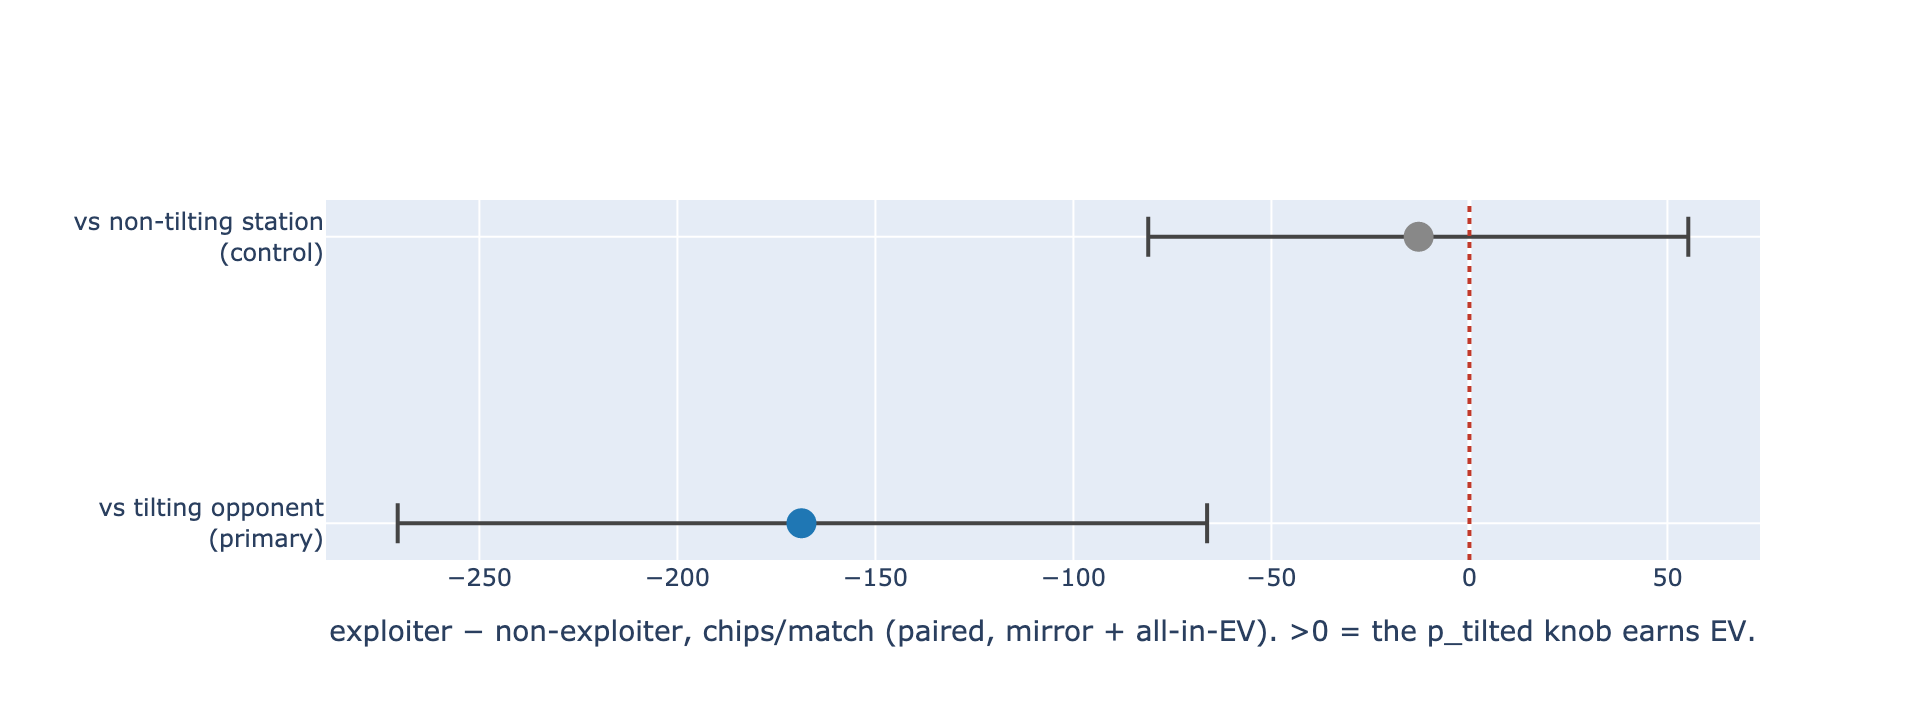

In [3]:
fig("exploitation.png")

## 3. Why the textbook counter-policy backfired

**The mechanism.** The disciplined baseline *already* beats the tilter (+533 chips/match): a tight-ish value-bettor punishes a loose-aggressive opponent by betting for value and folding marginal spots. "Call lighter / value-bet thinner" is the right counter to an opponent that *over-bluffs*, but this tilter is a loose-aggressive **maniac** (plays ~any hand and raises ~always when tilted), so calling lighter pays off its *value* and value-betting thinner walks into its re-raises. Against a maniac the correct adjustment is to **tighten and trap**, not loosen. The control confirms the mechanism: the same knob is ~neutral vs a *passive* station (which doesn't punish loosening) but loses vs the *aggressive* tilter. This is the **exploitation-vs-exploitability tradeoff** made concrete: a deviation tuned for one opponent archetype is counter-exploited by another.

**What the pre-registration caught.** An exploratory `n=6` smoke check (run only to confirm the script executed, and explicitly *not* used to set the frozen config) happened to show a **+152** paired delta. The pre-registered, properly-powered `n=300` run **overturned it to −169**. The small-sample peek was noise. Reporting the powered, pre-committed result over the tempting peek, and *not* flipping the knob's sign post-hoc and re-running until it "works": that is exactly what pre-registration is for. In a trading backtest this is the difference between a strategy that looks great on 6 days and bleeds over 300.

### The §13 takeaway, and the way forward

The pre-registered test resolves a **negative**: conditioning the policy on detected tilt via this a-priori DBR-style counter-policy *reduces* EV against this loose-aggressive tilter (−169 chips/match, 95% CI [−271, −66], sign-test p≈0.04) relative to a disciplined non-exploiting baseline, because the baseline already exploits the tilter, and loosening walks into its aggression. Measured vs *this* opponent only; no Nash-safety claim is made or implied (an exploiter is itself counter-exploitable).

This negative is not the end of the story. It diagnosed two fixable problems. First, the heads-up bust-match metric has a path-dependent variance (per-seed SD near 800 chips) so large it can swamp a small edge. Second, the hand-tuned knob was the wrong counter for a maniac. The next two sections fix both, and the result turns positive. See `PREREGISTRATION.md` §13 and `docs/V2_RESEARCH_ROADMAP.md`.

## 4. The fix, part one: exact exploitation with RNR (§14)

The literature names both fixes for §13 (`docs/V2_RESEARCH_ROADMAP.md`): use the validated Restricted Nash Response (RNR, Johanson and Bowling) instead of a hand-tuned knob, and measure on Leduc where EV is exact, so there is no bust-match variance to swamp a small edge.

RNR restricts the opponent to play a fixed strategy with probability `p` and a free, regret-minimised strategy with probability `1-p`. `p=0` is Nash, `p=1` is the exact best response, and intermediate `p` traces the exploitation-vs-exploitability frontier (`src/leduc_rnr.py`). Against three exploitable opponents the gain over Nash is strictly positive and exactly measured, with zero sampling variance.

The honest boundary: here the opponent is handed to the solver exactly, so this isolates the exploitation mechanism and its tradeoff. It reproduces validated RNR theory on this game, the same way notebook 02 reproduced Nash convergence, rather than introducing a new algorithm. The positive sign was guaranteed by construction. §15 is where that gift is taken away.

§14 Restricted Nash Response on exact Leduc (opponent HANDED exactly; EV over all 120 deals,
zero sampling variance):

  station  : Nash EV +0.50  ->  max RNR gain over Nash +0.96
  maniac   : Nash EV +0.21  ->  max RNR gain over Nash +2.16
  uniform  : Nash EV +0.59  ->  max RNR gain over Nash +1.50

  all four validation gates pass: True
  (p=0 reproduces Nash, p=1 matches the independently computed exact best response, EV monotone in p)


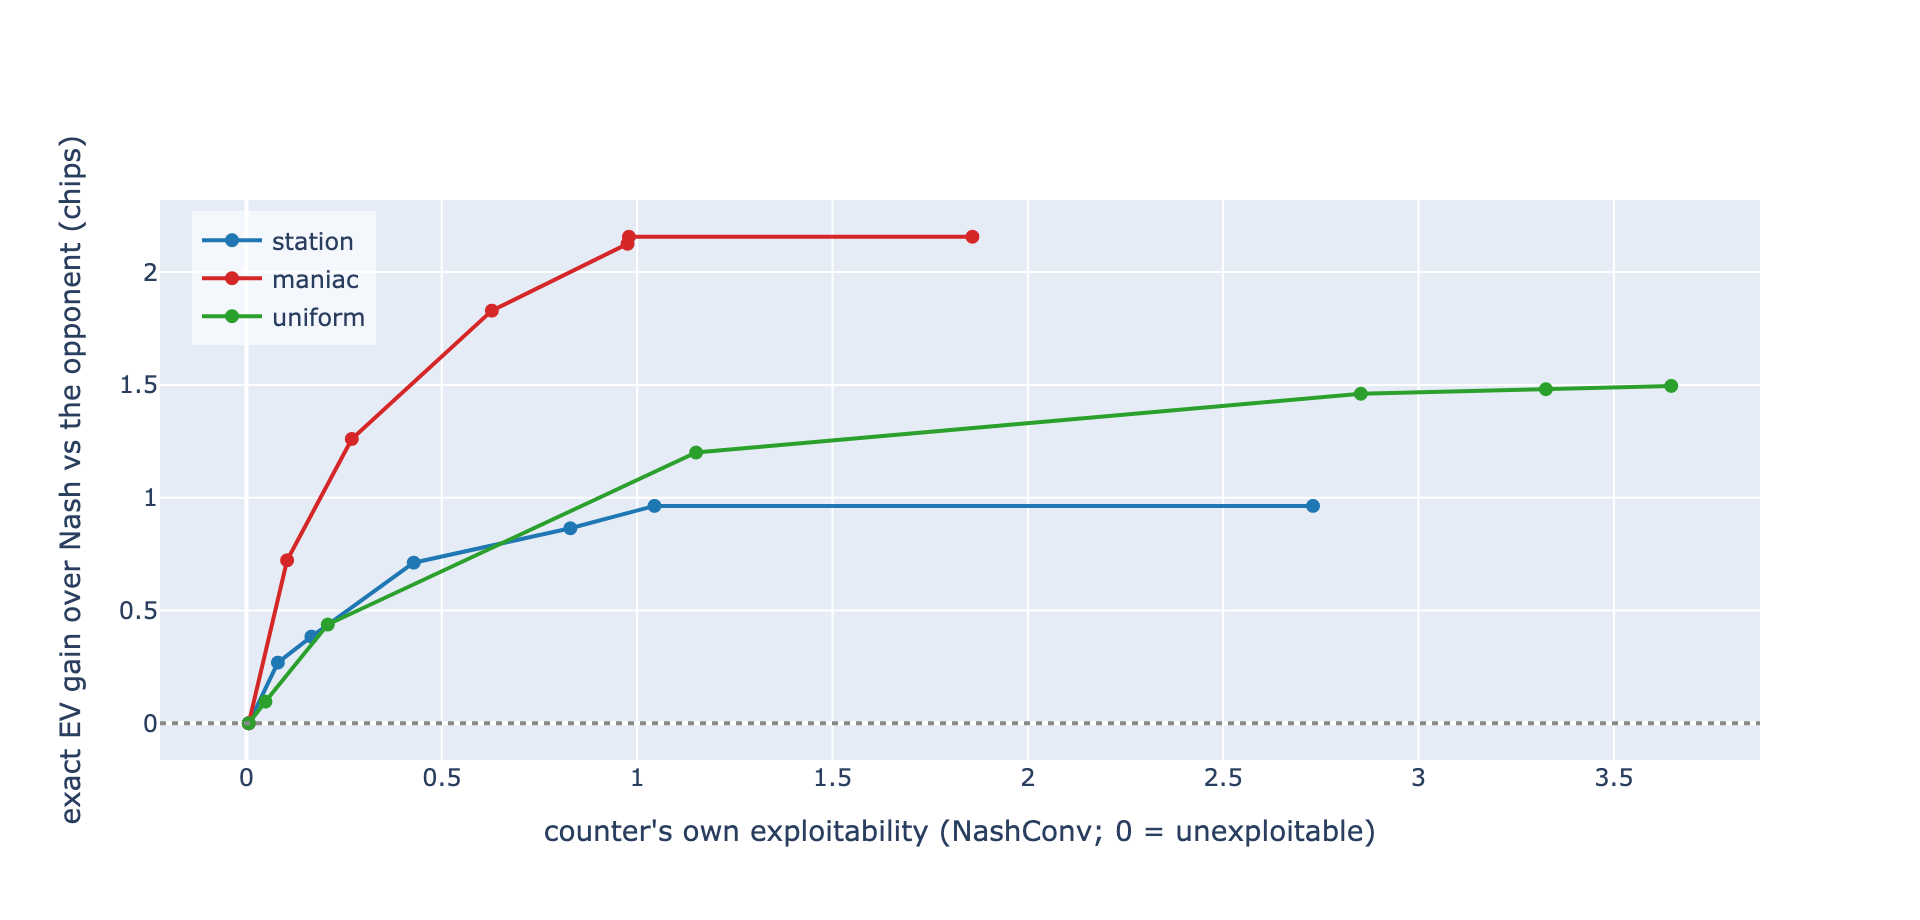

In [4]:
r = load("rnr_frontier.json")
print("§14 Restricted Nash Response on exact Leduc (opponent HANDED exactly; EV over all 120 deals,")
print("zero sampling variance):\n")
for name, o in r["opponents"].items():
    print(f"  {name:9s}: Nash EV {o['ev_nash_vs_opp']:+.2f}  ->  max RNR gain over Nash {o['max_gain_over_nash']:+.2f}")
print(f"\n  all four validation gates pass: {r['all_gates_pass']}")
print("  (p=0 reproduces Nash, p=1 matches the independently computed exact best response, EV monotone in p)")
fig("rnr_frontier.png")

## 5. The fix, part two: detect-then-exploit (§15)

§14 handed the solver the opponent's exact strategy, so the positive was guaranteed by construction: best-responding to a known weak opponent cannot do worse than Nash. §15 removes that gift, which is the honest, non-trivial question. Can you still exploit when you have to *learn* the opponent first?

The pipeline (`src/leduc_dbr.py`): the hero plays Nash, observes `N` hands, estimates the opponent as a Dirichlet-smoothed frequency table, then runs RNR on the *estimate*, scored by exact EV against the *true* opponent. Best-responding to a wrong estimate can lose, so a positive gain here is empirical, not a theorem.

Two findings, both pre-registered (`PREREGISTRATION.md` §15):

- **The reliable positive (G2).** With the conservative `p=0.5` and 40 observed hands, every opponent is beaten over Nash, each 95% CI excluding zero. Exploitation survives realistic detection.
- **The cautionary tale (G1, and why it is the point).** A raw best response (`p=1`) to the always-raise maniac *loses* to Nash on average. The maniac ends hands fast, so it visits its info-sets too sparsely to estimate, and the best response exploits a passivity that is not there. The pre-committed validity gate fails for exactly this reason. A restricted response (`p<1`) is what keeps exploitation from turning into a loss. This is the data-biased-response lesson of Johanson and Bowling, confirmed here on Leduc.

In the figure, the four solid lines (conservative `p=0.5`) all sit above the Nash line; the dotted maniac line (raw `p=1`) sits below it.

§15 detect-then-exploit (opponent ESTIMATED from N hands, then RNR on the estimate;
exact EV vs the TRUE opponent over all 120 deals):

  G2, the reliable positive at N=40 with the conservative p=0.5 (95% CI lower bound > 0 for all):
    station       gain over Nash +0.745   95% CI lo +0.716
    maniac        gain over Nash +1.314   95% CI lo +1.168
    uniform       gain over Nash +1.127   95% CI lo +1.074
    loose_passive gain over Nash +0.776   95% CI lo +0.735

  G1, the caveat: a raw best response (p=1) to the maniac at N=400 = -0.150,
    a LOSS to Nash on average (it visits its info-sets too sparsely to estimate).

  verdict flags:  G1=False  G2=True  G3=True


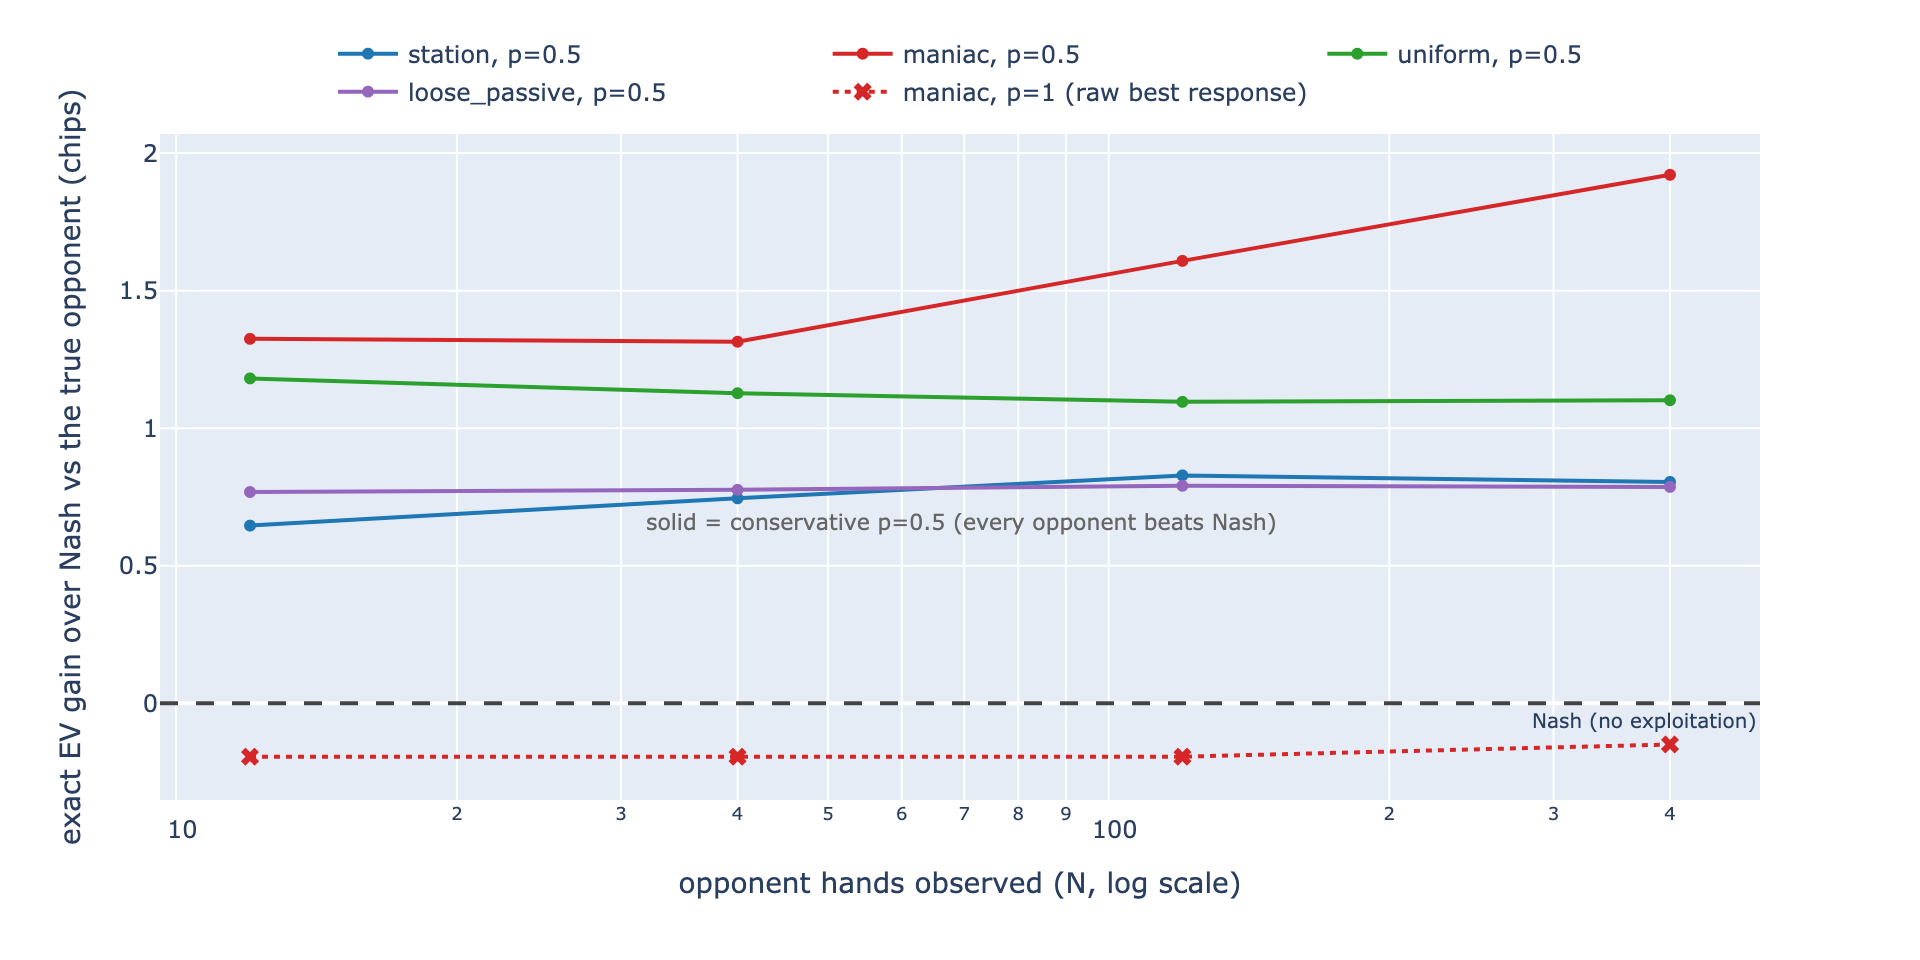

In [5]:
b = load("dbr_frontier.json")
mN = b["protocol"]["moderate_N"]
print("§15 detect-then-exploit (opponent ESTIMATED from N hands, then RNR on the estimate;")
print("exact EV vs the TRUE opponent over all 120 deals):\n")
print(f"  G2, the reliable positive at N={mN} with the conservative p=0.5 (95% CI lower bound > 0 for all):")
for name, o in b["opponents"].items():
    g = o["grid"][f"N{mN}_p0.5"]
    print(f"    {name:13s} gain over Nash {g['mean_gain']:+.3f}   95% CI lo {g['ci_lo']:+.3f}")
m = b["opponents"]["maniac"]["grid"]["N400_p1.0"]
print(f"\n  G1, the caveat: a raw best response (p=1) to the maniac at N=400 = {m['mean_gain']:+.3f},")
print(f"    a LOSS to Nash on average (it visits its info-sets too sparsely to estimate).")
print(f"\n  verdict flags:  G1={b['G1_large_N_recovers_ceiling']}  "
      f"G2={b['G2_detection_positive']}  G3={b['G3_overfitting_signature']}")
fig("dbr_frontier.png")

### The arc, honestly

Read top to bottom, this is the project's strongest result. A pre-registered exploitation attempt resolved *negative* (§13), for two reasons a literature review made precise. Fixing both gave an exact, reliable positive (§14). Removing the last crutch, the handed-over opponent, and forcing the bot to estimate it from data, still left a positive with a conservative response (§15), alongside a sharp account of when a raw best response loses.

So the honest answer to "can you beat Nash by exploiting a suboptimal opponent" is **yes**, with a measured price (the counter's own exploitability rises with `p`) and a named failure mode (a raw best response to a sparsely-observed opponent can lose). That account, not a single headline win, is the deliverable. It is the same discipline as the rest of the repo: state the negative, find its cause, fix it, and report the positive with its limits intact. The directions this arc does not yet take are mapped in [`../FUTURE_WORK.md`](../FUTURE_WORK.md).